In [ ]:
!pip install --upgrade pip
!pip install "iqm-client[qiskit]"
!pip install qrisp[iqm]
!pip install numpy==2.0
!pip install matplotlib
!pip install pylatexenc

In [ ]:
from iqm.qiskit_iqm import IQMProvider
import numpy as np

provider = IQMProvider("https://resonance.meetiqm.com",
                       quantum_computer="emerald",
                       token=input("Input your IQM Resonance token"))
backend = provider.get_backend()

Input your IQM Resonance tokenmAXs7S0MCfgGJ2/k3no+YnEDrdE0yi7OGOB6dXj6AwYBnBT3oN10oIQtIbVmYeIk


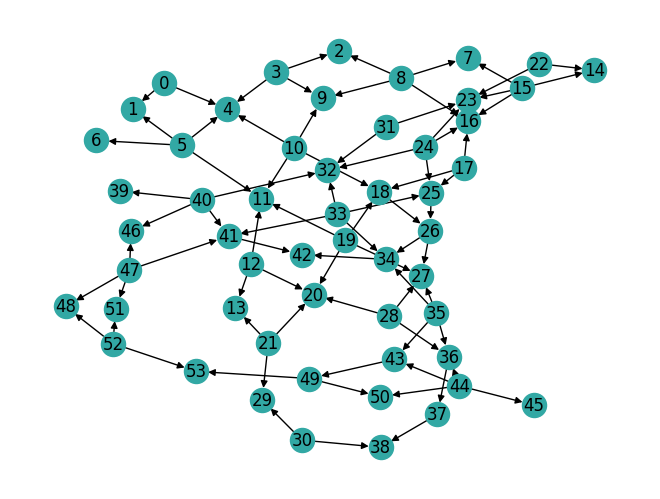

In [ ]:
from rustworkx.visualization import mpl_draw
from rustworkx import spring_layout

mpl_draw(backend.coupling_map.graph, arrows=True, with_labels=True, node_color='#32a8a4', pos=spring_layout(backend.coupling_map.graph, num_iter=200))

## Stablizer Measurements (16)

In [ ]:
from iqm.qiskit_iqm import IQMProvider
from qiskit.transpiler import Layout

# ---- Choose a physical subset by name (as in Script A) ----
qubits_names = [
    "QB35",
    "QB27",
    "QB19",
    "QB18",
    "QB26",
    "QB25",
    "QB33",
    "QB34",
    "QB42",
    "QB41",
    # "QB47",
    # "QB48",
    # "QB49",
    # "QB53",
    # "QB54",
]

qubits = [backend.qubit_name_to_index(name) for name in qubits_names]

# reduced coupling map only involving those physical qubits
reduced_coupling_map = [
    list(edge) for edge in backend.coupling_map
    if set(edge).issubset(set(qubits))
]

# Fixed mapping: logical i -> physical qubits[i]
initial_layout = qubits  # Qiskit accepts int-list layouts in transpile

def check_chain_connectivity(qubits, reduced_coupling_map):
    edges = {tuple(sorted(e)) for e in reduced_coupling_map}
    missing = []
    for i in range(len(qubits) - 1):
        a, b = qubits[i], qubits[i+1]
        if tuple(sorted((a, b))) not in edges:
            missing.append((i, i+1, a, b))
    if missing:
        print("WARNING: Missing physical couplings for intended chain edges:")
        for (i, j, a, b) in missing:
            print(f"  logical ({i},{j}) -> physical ({a},{b}) NOT in reduced map")
    else:
        print("Chain connectivity OK for intended mapping.")

check_chain_connectivity(qubits, reduced_coupling_map)


In [ ]:
from qiskit import QuantumCircuit
from typing import List

def build_cluster_state_parallel(num_qb: int) -> QuantumCircuit:
    """
    1D cluster state prep with CZ gates scheduled in two parallel layers:
      - H on all qubits
      - CZ on (0,1), (2,3), ...
      - barrier
      - CZ on (1,2), (3,4), ...
      - barrier
    """
    qc = QuantumCircuit(num_qb, name=f"cluster_1d_parallel_{num_qb}")

    for q in range(num_qb):
        qc.h(q)

    # Even edges
    for q in range(0, num_qb - 1, 2):
        qc.cz(q, q + 1)
    qc.barrier()

    # Odd edges
    for q in range(1, num_qb - 1, 2):
        qc.cz(q, q + 1)
    qc.barrier()

    return qc


class BitstringWindowError(ValueError):
    """Raised when inputs to generate_bitstrings() are invalid."""
    pass


def generate_bitstrings(bitstring: int, k: int) -> List[str]:
    """
    Generate all bitstrings of length `bitstring` such that among indices {k-1, k, k+1}
    that are in-bounds, the number of 1s in that window is EVEN.

    Args:
        bitstring: length of the bitstring (must be positive int)
        k: zero-based index into the bitstring (must satisfy 0 <= k < bitstring)

    Returns:
        List of bitstrings as strings of '0'/'1'.

    Raises:
        BitstringWindowError: for invalid inputs
    """
    # --- Type checks (catch floats/strings/etc.) ---
    if not isinstance(bitstring, int) or isinstance(bitstring, bool):
        raise BitstringWindowError(f"bitstring must be an int > 0, got {type(bitstring).__name__}")
    if not isinstance(k, int) or isinstance(k, bool):
        raise BitstringWindowError(f"k must be an int, got {type(k).__name__}")

    # --- Value checks ---
    if bitstring <= 0:
        raise BitstringWindowError(f"bitstring must be > 0, got {bitstring}")
    if k < 0 or k >= bitstring:
        raise BitstringWindowError(
            f"k is out of bounds: got k={k}, but valid range is 0..{bitstring-1} for bitstring={bitstring}"
        )

    window_idxs = [idx for idx in (k - 1, k, k + 1) if 0 <= idx < bitstring]
    other_idxs = [idx for idx in range(bitstring) if idx not in window_idxs]

    results: List[str] = []

    # Window patterns: descending
    for win_pat in range((1 << len(window_idxs)) - 1, -1, -1):
        ones_cnt = win_pat.bit_count()  # Python 3.8+: use bin(win_pat).count("1") if needed
        if (ones_cnt & 1) != 0:
            continue  # reject odd parity

        # Other bits: ascending
        for oth_pat in range(0, 1 << len(other_idxs)):
            bits = ['0'] * bitstring

            for pos, idx in enumerate(window_idxs):
                shift = (len(window_idxs) - 1 - pos)
                bits[idx] = '1' if ((win_pat >> shift) & 1) else '0'

            for pos, idx in enumerate(other_idxs):
                shift = (len(other_idxs) - 1 - pos)
                bits[idx] = '1' if ((oth_pat >> shift) & 1) else '0'

            results.append("".join(bits))

    return results

In [ ]:
from qiskit.visualization import plot_histogram
from qiskit import transpile

def transpile_fixed(qc, backend, reduced_coupling_map, initial_layout, opt_level=3):
    return transpile(
        qc,
        backend=backend,
        coupling_map=reduced_coupling_map,
        initial_layout=initial_layout,
        optimization_level=opt_level,
    )

def count_sum(count, size, marker):
  bitstring_list = generate_bitstrings(size,marker)
  sum = 0
  for bitstring in bitstring_list:
    sum += count.get(bitstring, 0)
  return sum


def entanglement_demo(num_qb,shots=10000, plot=True):
  qc = build_cluster_state(num_qb)

  # Part 1: ZXZX...
  qc_p1 = qc.copy(name='qc_p1')
  for i in range(num_qb):
    if i % 2 == 1:
      qc_p1.h(i)
  qc_p1.measure_all()
  qc_p1.draw("mpl",  style="clifford")
  qc_p1_transpiled = transpile_fixed(qc_p1, backend=backend)
  job1 = backend.run(qc_p1_transpiled, shots = shots)
  res1 = job1.result()
  counts1 = res1.get_counts()

  # Part 2: XZXZ....
  qc_p2 = qc.copy(name='qc_p2')
  for i in range(num_qb):
    if i % 2 == 0:
      qc_p2.h(i)
  qc_p2.measure_all()
  qc_p2_transpiled = transpile_fixed(qc_p2, backend=backend)
  job2 = backend.run(qc_p2_transpiled, shots = shots)
  res2 = job2.result()
  counts2 = res2.get_counts()

  K_list = np.zeros((num_qb))
  for i in range(num_qb):
    if i % 2 == 1:
      K_list[i] = 2*count_sum(counts1,num_qb, num_qb-1-i)/shots - 1
    else:
      K_list[i] = 2*count_sum(counts2,num_qb, num_qb-1-i)/shots - 1

  print(K_list)
  print(num_qb-1-np.sum(K_list))

  if plot:
    plot_histogram(counts1)
    plot_histogram(counts2)

  return None


In [ ]:
import random

def generate_random_bitstrings(m: int, n: int, seed: int = 0):
    rng = random.Random(seed)
    seen = set()
    out = []
    if m > 2**n:
        raise ValueError("m exceeds number of distinct n-bit strings")
    while len(out) < m:
        s = "".join("1" if rng.random() < 0.5 else "0" for _ in range(n))
        if s not in seen:
            seen.add(s)
            out.append(s)
    return out

def apply_local_z_flips(qc: QuantumCircuit, bitstring: str) -> QuantumCircuit:
    out = qc.copy()
    for i, b in enumerate(bitstring):
        if b == "1":
            out.z(i)
    out.barrier()
    return out


In [ ]:
entanglement_demo(4)

Progress in queue:   0%|          | 0/2 [00:00<?, ?it/s]

Progress in queue:   0%|          | 0/2 [00:00<?, ?it/s]

[0.8984 0.8816 0.8952 0.913 ]
-0.5882000000000005


In [ ]:
from qiskit.visualization import plot_histogram
from qiskit import transpile
def common_list(size, parity):
  if parity == 'odd':
      sets = [generate_bitstrings(size, i) for i in range(1,size,2)]
  elif parity == 'even':
      sets = [generate_bitstrings(size, i) for i in range(0,size,2)]

  common = set.intersection(*(set(s) for s in sets))
  return list(common)

def common_sum(count, num_qb, parity):
  bitstring_list = common_list(num_qb, parity)
  sum = 0
  for bitstring in bitstring_list:
    sum += count.get(bitstring, 0)
  return sum

def count_sum(count, size, marker):
  bitstring_list = generate_bitstrings(size,marker)
  sum = 0
  for bitstring in bitstring_list:
    sum += count.get(bitstring, 0)
  return sum

def witness_v2(num_qb,shots=10000, plot=True):
  qc = build_cluster_state(num_qb)

  # Part 1: ZXZX...
  qc_p1 = qc.copy(name='qc_p1')
  for i in range(num_qb):
    if i % 2 == 1:
      qc_p1.h(i)
  qc_p1.measure_all()
  qc_p1.draw("mpl",  style="clifford")
  qc_p1_transpiled = transpile(qc_p1, backend=backend)#, coupling_map=reduced_coupling_map, optimization_level=3)
  job1 = backend.run(qc_p1_transpiled, shots = shots)
  res1 = job1.result()
  counts1 = res1.get_counts()
  counts1 = {k[::-1]: v for k, v in counts1.items()}

  # Part 2: XZXZ....
  qc_p2 = qc.copy(name='qc_p2')
  for i in range(num_qb):
    if i % 2 == 0:
      qc_p2.h(i)
  qc_p2.measure_all()
  qc_p2_transpiled = transpile(qc_p2, backend=backend)#, coupling_map=reduced_coupling_map, optimization_level=3)
  job2 = backend.run(qc_p2_transpiled, shots = shots)
  res2 = job2.result()
  counts2 = res2.get_counts()
  counts2 = {k[::-1]: v for k, v in counts2.items()}

  # K_list = np.zeros((num_qb))

  # # Calculate individual stabilizers
  # for i in range(num_qb):
  #   if i % 2 == 1:
  #     K_list[i] = 2*count_sum(counts1,num_qb, i)/shots - 1
  #   else:
  #     K_list[i] = 2*count_sum(counts2,num_qb, i)/shots - 1

  # print(K_list)
  # print("Minimal Witness: ", num_qb-1-np.sum(K_list)) # Minimal witness

  # #Optimal witness

  # print("Optimal Witness: ",3-2*(common_sum(counts1, num_qb, 'odd')+ common_sum(counts2, num_qb, 'even'))/shots)


    # plot_histogram([counts1, counts2], legend=["run 1", "run 2"], color=["tab:blue", "tab:orange"])
    # plot_histogram(counts1)

  return counts1, counts2

In [ ]:
counts1, counts2 = witness_v2(16, shots=20000)
# plot_histogram(counts1)

Progress in queue:   0%|          | 0/2 [00:00<?, ?it/s]

Progress in queue:   0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
def stabilizer_calc(counts1, counts2, num_qb, shots=10000):
  K_list = np.zeros((num_qb))

  # Calculate individual stabilizers
  for i in range(num_qb):
    if i % 2 == 1:
      K_list[i] = 2*count_sum(counts1,num_qb, i)/shots - 1
    else:
      K_list[i] = 2*count_sum(counts2,num_qb, i)/shots - 1

  print(K_list)
  print("Minimal Witness: ", num_qb-1-np.sum(K_list)) # Minimal witness

  # Optimal witness

  print("Optimal Witness: ",3-2*(common_sum(counts1, num_qb, 'odd')+ common_sum(counts2, num_qb, 'even'))/shots)

  return num_qb-1-np.sum(K_list), 3-2*(common_sum(counts1, num_qb, 'odd')+ common_sum(counts2, num_qb, 'even'))/shots


In [ ]:
# plot_histogram(counts1)

KeyboardInterrupt: 

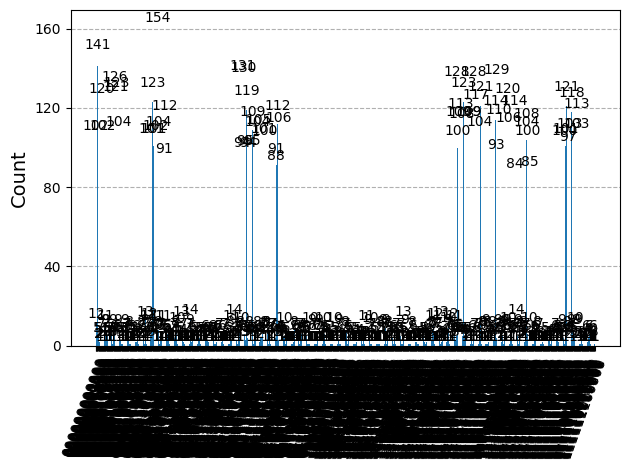

In [ ]:
# plot_histogram(counts2)

In [ ]:
def counts_to_raw_vector(counts, num_qb):
    # Dimension is 2^N (16 for 4 qubits)
    dim = 2**num_qb

    # Initialize a column vector of zeros
    vec = np.zeros(dim)

    for i in range(dim):
        # Generate the bitstring for the current index (e.g., 3 -> '0011')
        bitstring = format(i, f'0{num_qb}b')

        # Get raw count from dict, default to 0 if state was never measured
        raw_val = counts.get(bitstring, 0)

        # Place raw count in the vector
        vec[i] = raw_val

    return vec

def vector_to_counts(mitigated_vec, num_qb):
    """
    Converts a column vector back to a Qiskit-style count dictionary.
    """
    counts_dict = {}
    dim = len(mitigated_vec)

    for i in range(dim):
        # Convert index back to binary string (padded)
        bitstring = format(i, f'0{num_qb}b')

        # Get the value from the vector
        val = mitigated_vec[i]

        # We include all values, including negatives, to maintain
        # the mathematical integrity of the expectation value calculation.
        counts_dict[bitstring] = val

    return counts_dict

In [ ]:
from functools import reduce
def readout_matrix(count_vec0, count_vec1, num_qb, qb_pos):
  shots = np.sum(count_vec0)

  cc00 = 0
  cc01 = 0
  N = 2**num_qb
  for i in range(N):
    if (i//(2**(num_qb-1-qb_pos))) % 2 == 0:
      cc00 += count_vec0[i]
      cc01 += count_vec1[i]

  cc10 = shots - cc00
  cc11 = shots - cc01
  # print(count_vec0)
  return np.array([[cc00,cc01],[cc10,cc11]])/shots


def calibration_matrix_inv(counts_0, counts_1, num_qb):
  counts_0_vec = counts_to_raw_vector(counts_0, num_qb)
  counts_1_vec = counts_to_raw_vector(counts_1, num_qb)

  readout_matrices_inv = [np.linalg.inv(readout_matrix(counts_0_vec, counts_1_vec, num_qb, i)) for i in range(num_qb)]
  # print(readout_matrices[0].shape)
  # print(readout_matrices[0])

  # calibration_matrix_inv = reduce(np.kron, readout_matrices_inv)
  return readout_matrices_inv

def calibration_matrix(counts_0, counts_1, num_qb):
  counts_0_vec = counts_to_raw_vector(counts_0, num_qb)
  counts_1_vec = counts_to_raw_vector(counts_1, num_qb)

  readout_matrices = [readout_matrix(counts_0_vec, counts_1_vec, num_qb, i) for i in range(num_qb)]
  # print(readout_matrices[0].shape)
  # print(readout_matrices[0])

  # calibration_matrix_inv = reduce(np.kron, readout_matrices_inv)
  return readout_matrices


In [ ]:
def readout_calibration(num_qb, shots=10000):
  qc1 = QuantumCircuit(num_qb)
  qc1.measure_all()

  qc1_transpiled = transpile(qc1, backend=backend)
  job1 = backend.run(qc1_transpiled, shots = shots)
  res1 = job1.result()
  counts_0_cal = res1.get_counts()
  counts_0_cal = {k[::-1]: v for k, v in counts_0_cal.items()}

  qc2 = QuantumCircuit(num_qb)
  for i in range(num_qb):
    qc2.x(i)
  qc2.measure_all()

  qc2_transpiled = transpile(qc2, backend=backend)
  job2 = backend.run(qc2_transpiled, shots = shots)
  res2 = job2.result()
  counts_1_cal = res2.get_counts()
  counts_1_cal = {k[::-1]: v for k, v in counts_1_cal.items()}

  return counts_0_cal, counts_1_cal


def apply_kron_2x2(mats, x):
    """
    mats: list of 2x2 arrays, length n
    x: (2**n,) vector
    returns (mats[0] ⊗ mats[1] ⊗ ... ⊗ mats[n-1]) @ x
    """
    n = len(mats)
    t = x.reshape([2]*n)
    for k, M in enumerate(mats):
        t = np.tensordot(M, t, axes=([1],[k]))  # contract input axis
        t = np.moveaxis(t, 0, k)                # restore axis order
    return t.reshape(-1)

# y = apply_kron_2x2(mats, x)
def mat_mul(counts1, counts2, counts_0_cal, counts_1_cal, num_qb):
  Cinv_list = calibration_matrix_inv(counts_0_cal, counts_1_cal, num_qb)
  counts1_corrected = vector_to_counts(apply_kron_2x2(Cinv_list, counts_to_raw_vector(counts1, num_qb)),num_qb)
  counts2_corrected = vector_to_counts(apply_kron_2x2(Cinv_list, counts_to_raw_vector(counts2, num_qb)),num_qb)

  return counts1_corrected, counts2_corrected

def mat_mul_old(counts1, counts2, counts_0_cal, counts_1_cal, num_qb):
  Cinv_list = calibration_matrix_inv(counts_0_cal, counts_1_cal, num_qb)
  Cinv = reduce(np.kron, Cinv_list)
  counts1_corrected = vector_to_counts(Cinv@counts_to_raw_vector(counts1, num_qb),num_qb)
  counts2_corrected = vector_to_counts(Cinv@counts_to_raw_vector(counts2, num_qb),num_qb)

  return counts1_corrected, counts2_corrected

In [ ]:
counts_0_cal, counts_1_cal = readout_calibration(16, shots=20000)

Progress in queue:   0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
mat_list = calibration_matrix(counts_0_cal, counts_1_cal, 16)
print([np.diag(mat) for mat in mat_list])

[array([0.98465, 0.9744 ]), array([0.9907, 0.9768]), array([0.9942, 0.9652]), array([0.9837 , 0.97905]), array([0.97945, 0.9498 ]), array([0.9932 , 0.98725]), array([0.9772 , 0.94805]), array([0.99645, 0.9714 ]), array([0.9856 , 0.96895]), array([0.9796, 0.9743]), array([0.98645, 0.97895]), array([0.99235, 0.97855]), array([0.98835, 0.97095]), array([0.9912 , 0.97675]), array([0.98935, 0.97455]), array([0.9967, 0.99  ])]


In [ ]:
counts1_corr, counts2_corr = mat_mul(counts1, counts2, counts_0_cal, counts_1_cal, 16)

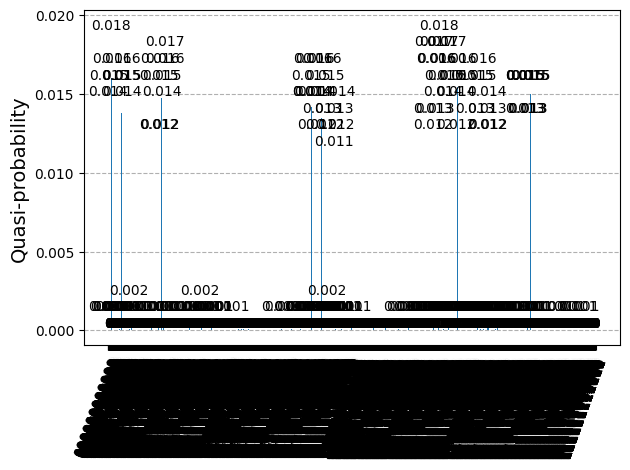

In [ ]:
plot_histogram(counts1_corr)

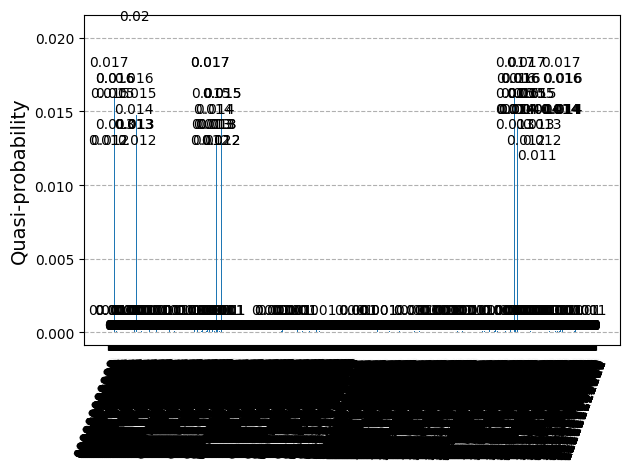

In [ ]:
plot_histogram(counts2_corr)

In [ ]:
mw, ow = stabilizer_calc(counts1_corr, counts2_corr, 16, shots=20000)

[0.92907763 0.92858898 0.95509736 1.00247575 0.95430219 0.98177679
 0.96030342 1.04137679 0.97040999 0.98290733 0.9628455  1.01354209
 0.95326267 0.97268266 0.92916832 0.93843403]
Minimal Witness:  -0.47625149860226657
Optimal Witness:  -0.3306450645176011


In [ ]:
mw, ow = stabilizer_calc(counts1, counts2, 16, shots=20000)

[0.8622 0.8267 0.8539 0.8603 0.8371 0.8274 0.8433 0.8907 0.8556 0.8643
 0.861  0.9113 0.8599 0.8705 0.856  0.8924]
Minimal Witness:  1.2273999999999994
Optimal Witness:  0.5626000000000002
